# **02: RECALL BOOSTING & CNN-RNN OPTIMIZATION**
### **Purpose: Improve recall performance through CNN-RNN hybrid architecture**
### Status: Performance enhancement - adds LSTM for temporal patterns
### Key Results: Enhanced recall for safety-critical failure detection
### Next: Ensemble approach in 03_hybrid_ensemble.ipynb

# Environment Setup

In [1]:
# 📦 Install Dependencies
%pip install pandas scikit-learn tensorflow matplotlib imbalanced-learn
%env SCIPY_ARRAY_API=1


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


# Imports

In [2]:
# 📦 ESSENTIAL IMPORTS ONLY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import sys
import os

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, 
    classification_report, roc_curve, auc,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

# TensorFlow/Keras
from tensorflow.keras.callbacks import EarlyStopping

# Custom utilities
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_weighted_model

# Data Loading & Preprocessing

In [3]:
# 1️⃣ LOAD AND PREPROCESS DATASET
print("📊 Loading dataset for recall optimization...")
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Original class distribution: {np.bincount(y_train)}")

📊 Loading dataset for recall optimization...
Training set: (8000, 5, 1)
Test set: (2000, 5, 1)
Original class distribution: [7722  278]


# Advanced Data Balancing

In [4]:
# 2️⃣ APPLY SMOTE FOR CLASS BALANCING
print("⚖️ Applying SMOTE oversampling...")
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train.reshape(X_train.shape[0], -1), y_train
)

# Reshape back to 3D for CNN-RNN
X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], 1)

print(f"Original distribution: {np.bincount(y_train)}")
print(f"Balanced distribution: {np.bincount(y_train_resampled)}")

⚖️ Applying SMOTE oversampling...
Original distribution: [7722  278]
Balanced distribution: [7722 7722]


# Build Weighted Model

In [5]:
# 3️⃣ BUILD WEIGHTED CNN-RNN MODEL
print("🏗️ Building weighted CNN-RNN architecture...")
model = build_weighted_model(input_shape=(X_train.shape[1], 1))
model.summary()

🏗️ Building weighted CNN-RNN architecture...


/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-11 15:07:32.714373: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-11 15:07:32.714572: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-11 15:07:32.714585: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1762870052.714928 18752729 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762870052.715148 18752729 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

# Class Weight Distribution

In [6]:
# 4️⃣ COMPUTE CLASS WEIGHTS FOR RECALL BOOST
print("⚖️ Computing balanced class weights...")
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print(f"Computed class weights: {class_weights}")
print("Using manual weights: {0: 1.0, 1: 5.0} for higher recall")

⚖️ Computing balanced class weights...
Computed class weights: {0: 0.518000518000518, 1: 14.388489208633093}
Using manual weights: {0: 1.0, 1: 5.0} for higher recall


# Model Training

In [7]:
# 5️⃣ TRAIN MODEL WITH RECALL OPTIMIZATION
print("🚀 Training model with recall boosting...")

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with weighted classes (favor failure detection)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 5.0},  # Higher weight for failures
    callbacks=[early_stop]
)

print("✅ Training completed!")

🚀 Training model with recall boosting...
Epoch 1/50


2025-11-11 15:07:45.614362: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9113 - loss: 0.5606 - recall: 0.0823 - val_accuracy: 0.9606 - val_loss: 0.1874 - val_recall: 0.2424
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9523 - loss: 0.3732 - recall: 0.2720 - val_accuracy: 0.9631 - val_loss: 0.1346 - val_recall: 0.3333
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9554 - loss: 0.2971 - recall: 0.4325 - val_accuracy: 0.9531 - val_loss: 0.1561 - val_recall: 0.4848
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9444 - loss: 0.3005 - recall: 0.4325 - val_accuracy: 0.9563 - val_loss: 0.1425 - val_recall: 0.4242
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9570 - loss: 0.2729 - recall: 0.5506 - val_accuracy: 0.9525 - val_loss: 0.1459 - val_recall: 0.4697
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9453 - loss: 0.3184 - recall: 0.4883 - val_accuracy: 0.9500 - val_loss: 0.1511 - val_recall: 0.4545
Epoch 7/5

# Model Evaluation

In [8]:
# 6️⃣ EVALUATE RECALL-OPTIMIZED PERFORMANCE
print("📊 Evaluating recall-boosted model...")

# Basic evaluation
loss, accuracy, recall = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Loss: {loss:.4f}")

# Get predictions for detailed analysis
y_pred = model.predict(X_test).flatten()
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

# Additional metrics
precision = precision_score(y_test, y_pred_labels)
f1 = f1_score(y_test, y_pred_labels)
print(f"Test Precision: {precision:.4f}")
print(f"Test F1 Score: {f1:.4f}")

📊 Evaluating recall-boosted model...
Test Accuracy: 0.9655
Test Recall: 0.2459
Test Loss: 0.1152
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test Precision: 0.3947
Test F1 Score: 0.3030


# Training Histroy Visualization

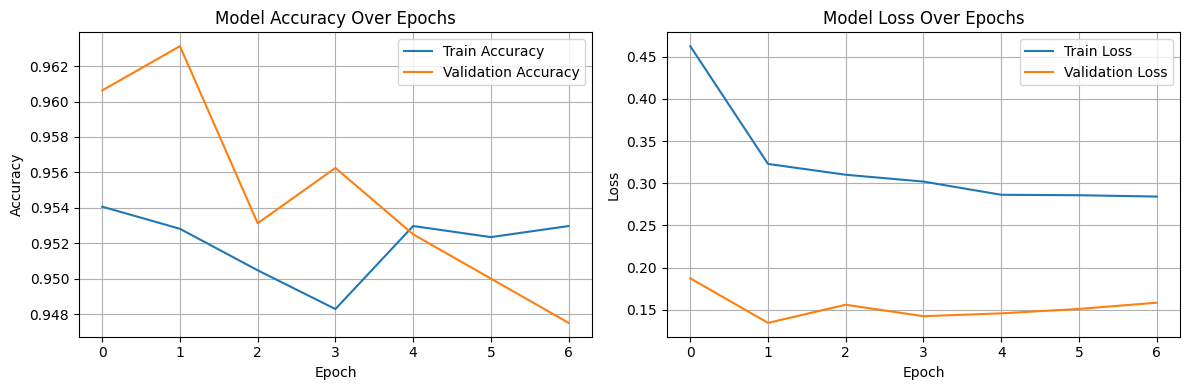

In [9]:
# 7️⃣ TRAINING HISTORY VISUALIZATION
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix Analysis

<Figure size 600x500 with 0 Axes>

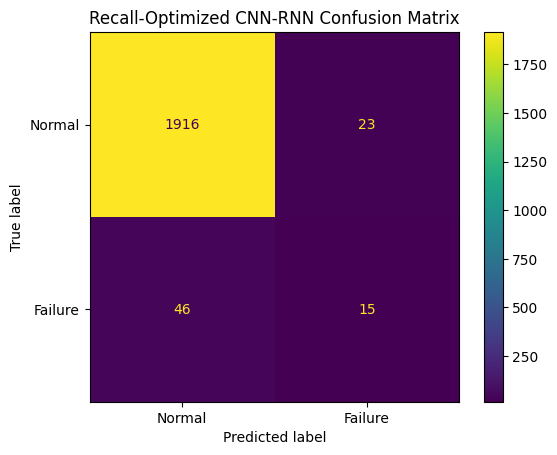

True Negatives: 1916
False Positives: 23
False Negatives: 46
True Positives: 15


In [10]:
# 8️⃣ CONFUSION MATRIX ANALYSIS
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_labels)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure']).plot()
plt.title("Recall-Optimized CNN-RNN Confusion Matrix")
plt.show()

# Print detailed confusion matrix stats
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")  
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# ROC Curve Analysis

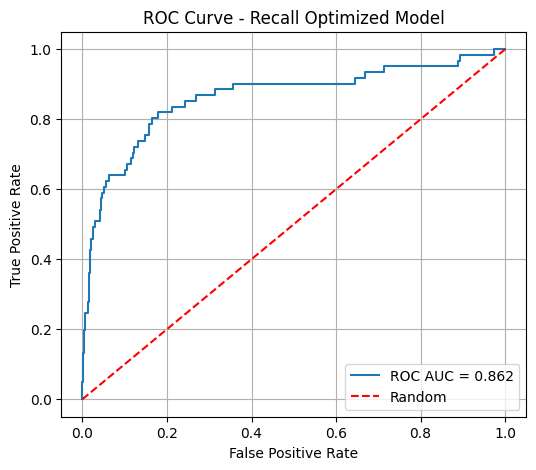

In [11]:
# 9️⃣ ROC CURVE ANALYSIS
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Recall Optimized Model")
plt.legend()
plt.grid(True)
plt.show()

# Threshold Optimization

🎯 Optimizing threshold for best F1 score...


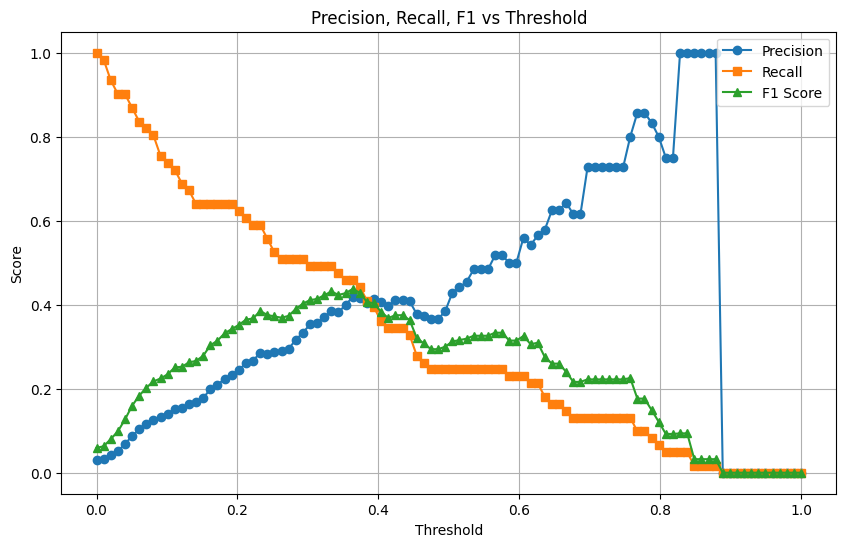

✅ Best threshold: 0.364
📈 Best F1 Score: 0.4375


In [12]:
# 🔟 THRESHOLD OPTIMIZATION FOR BEST F1
print("🎯 Optimizing threshold for best F1 score...")

thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_pred > t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

# Plot threshold analysis
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='s')
plt.plot(thresholds, f1s, label='F1 Score', marker='^')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Find best threshold
best_f1_idx = np.argmax(f1s)
best_threshold = thresholds[best_f1_idx]
best_f1 = f1s[best_f1_idx]

print(f"✅ Best threshold: {best_threshold:.3f}")
print(f"📈 Best F1 Score: {best_f1:.4f}")

# Final Evaluation with Optimized Threshold

In [13]:
# 1️⃣1️⃣ FINAL EVALUATION WITH OPTIMIZED THRESHOLD
print(f"📊 Final evaluation with threshold = {best_threshold:.3f}")

# Apply optimal threshold
y_pred_final = (y_pred > best_threshold).astype(int)

# Detailed classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, digits=4))

# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\nFinal Confusion Matrix:")
print(cm_final)

📊 Final evaluation with threshold = 0.364

📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9829    0.9799    0.9814      1939
           1     0.4179    0.4590    0.4375        61

    accuracy                         0.9640      2000
   macro avg     0.7004    0.7195    0.7095      2000
weighted avg     0.9657    0.9640    0.9648      2000


Final Confusion Matrix:
[[1900   39]
 [  33   28]]


# Save Model & Results

In [14]:
# 1️⃣2️⃣ SAVE RECALL-OPTIMIZED MODEL AND RESULTS
print("💾 Saving recall-optimized model and results...")

# Save model
model.save("../models/cnn_rnn_recall_optimized.keras")

# Save metrics
with open("../results/recall_optimized_metrics.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Metric", "Value"])
    writer.writerow(["Loss", loss])
    writer.writerow(["Accuracy", accuracy])
    writer.writerow(["Recall", recall])
    writer.writerow(["Precision", precision])
    writer.writerow(["F1_Score", f1])
    writer.writerow(["ROC_AUC", roc_auc])
    writer.writerow(["Best_Threshold", best_threshold])
    writer.writerow(["Best_F1", best_f1])

# Save predictions
results_df = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "Predicted_Probability": y_pred,
    "Predicted_Label_Default": y_pred_labels,
    "Predicted_Label_Optimized": y_pred_final
})
results_df.to_csv("../results/recall_optimized_predictions.csv", index=False)

print("✅ Recall optimization completed!")
print("📈 Next: Run 03_hybrid_ensemble.ipynb for ensemble approach")

💾 Saving recall-optimized model and results...
✅ Recall optimization completed!
📈 Next: Run 03_hybrid_ensemble.ipynb for ensemble approach
